In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import missingno as msno

In [33]:
# Load the data from the CSV file
df = pd.read_csv("../data/raw/data-v5.csv")

# Display the first few rows to verify the data was loaded correctly
df.head(1)

,propertyId,localityName,postalCode,typeOfProperty,subtypeOfProperty,price,typeOfSale,numberOfRooms,livingArea,equippedKitchen,...,hasThermicPanels,hasCollectiveWaterHeater,hasDoubleGlazing,epcScore,primaryEnergyConsumptionPerSqm,renovationObligation,cadastralIncome,parkingCountIndoor,parkingCountOutdoor,parkingCountClosedBox
0,20665504,Virton Ruette,6760,0,0,249000,0,8,164,2,...,-1,-1,-1,6,486,-1,570,1,1,-1


---

## Missing values

<Axes: >

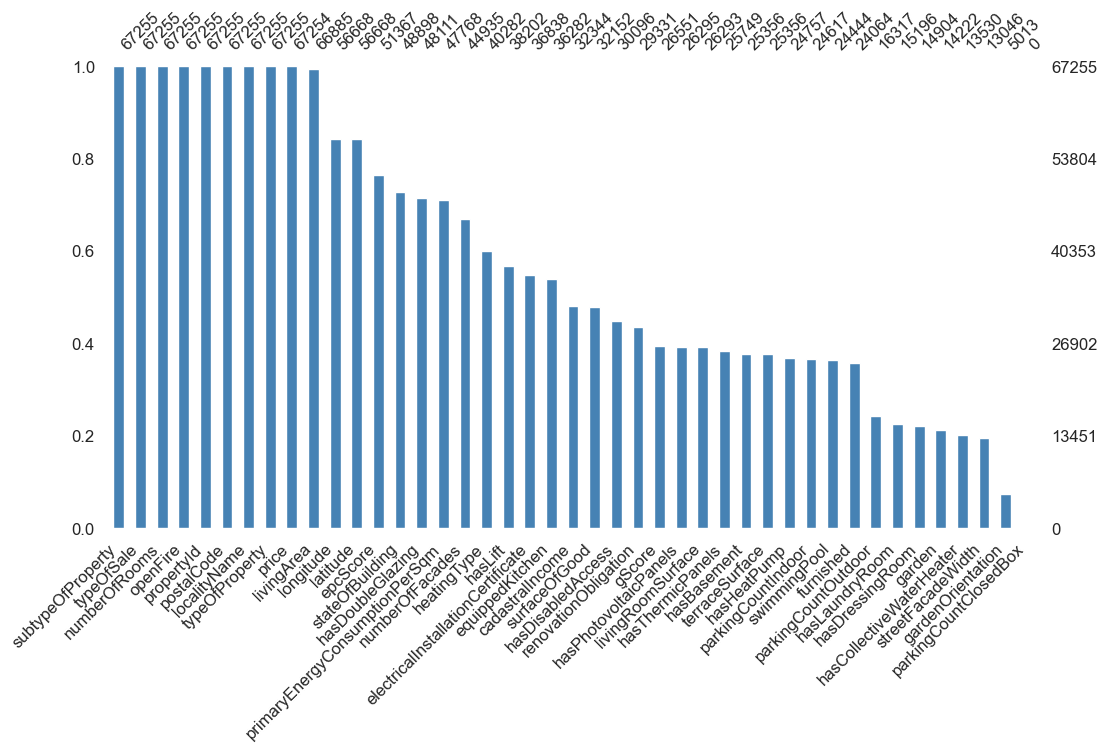

In [34]:
# Replace all -1 values with NaN across the dataframe
df = df.replace(-1, pd.NA)

# Better visualization of missing values
msno.bar(df, color="steelblue", figsize=(12, 6), fontsize=12, sort="descending") 


Revert to -1 for analysis

In [35]:
df.replace(pd.NA, -1, inplace=True)

C:\Users\ImJus\AppData\Local\Temp\ipykernel_25668\2791573313.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(pd.NA, -1, inplace=True)


---

## Heatmap of correlation

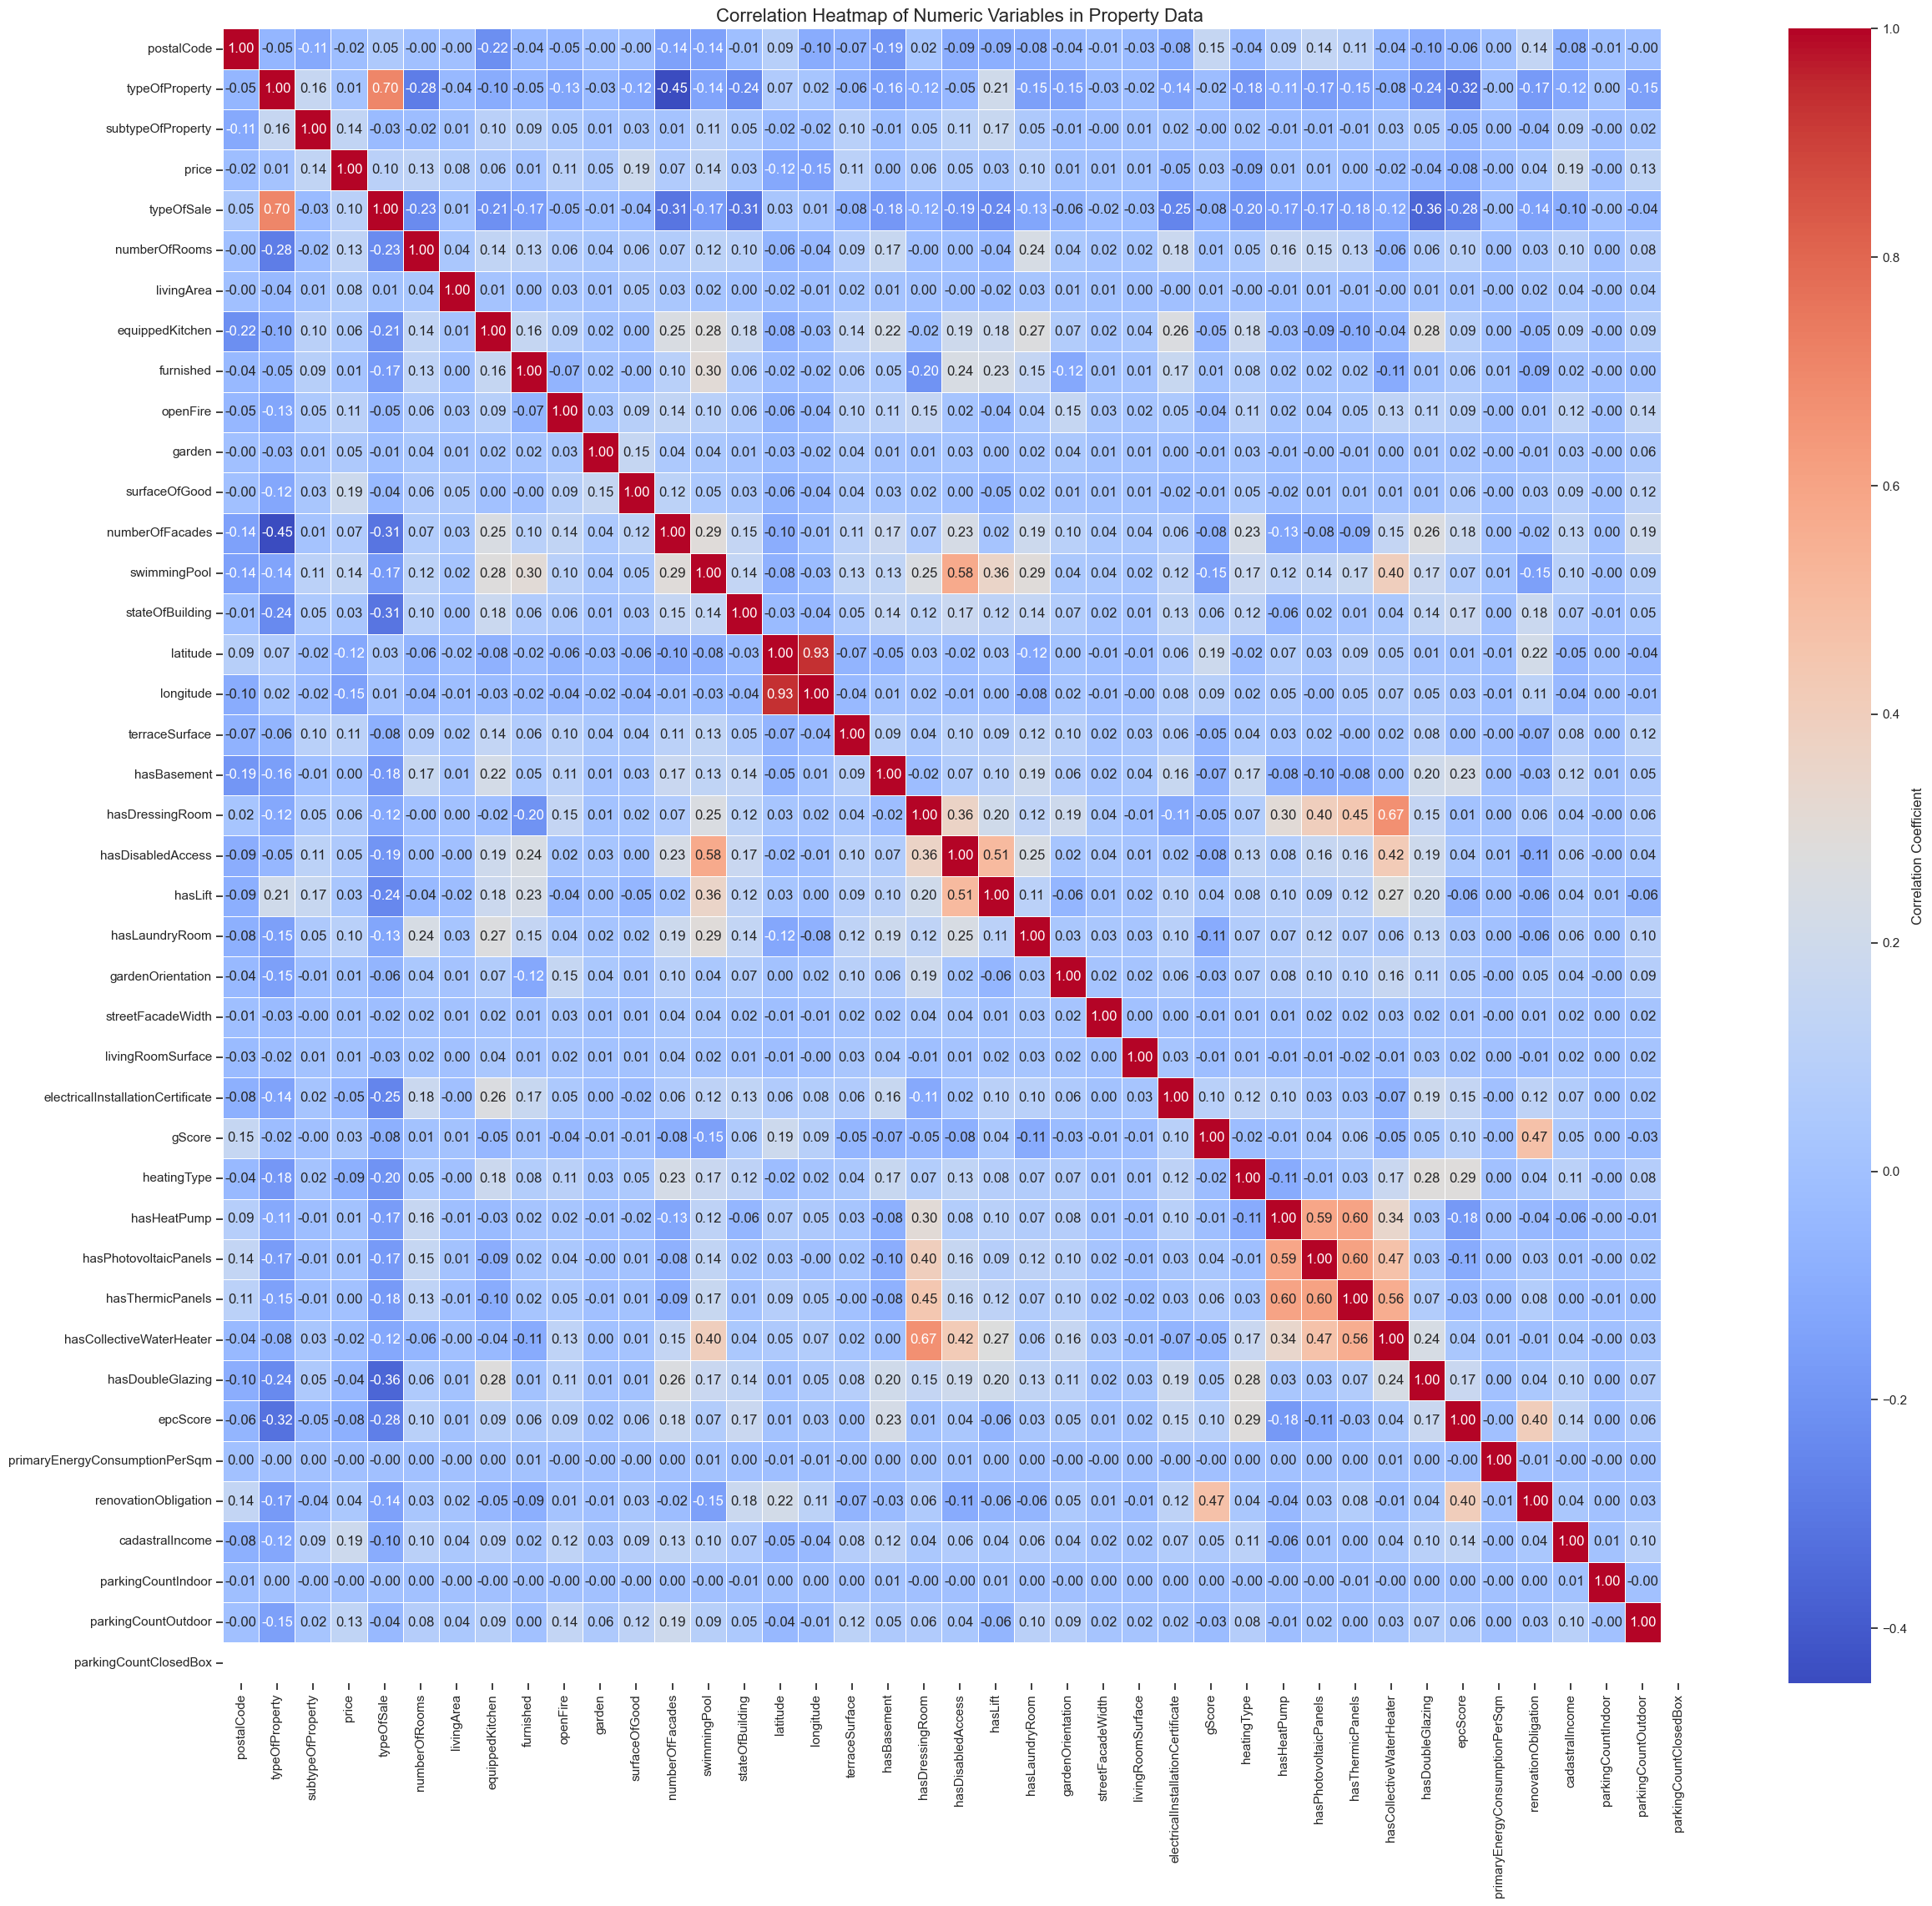

In [36]:
# Calculate the correlation matrix, excluding propertyId
correlation_matrix = df.drop(columns=['propertyId', 'localityName']).corr()

# Create a figure with appropriate size
plt.figure(figsize=(25, 23))

# Create a heatmap with value labels
heatmap = sns.heatmap(
    correlation_matrix, 
    annot=True,  # Show values on the heatmap
    cmap='coolwarm',  # Color map
    fmt='.2f',  # Format for the annotations (2 decimal places)
    linewidths=0.5,  # Width of the lines that divide each cell
    cbar_kws={'label': 'Correlation Coefficient'}  # Colorbar label
)

# Set title
plt.title('Correlation Heatmap of Numeric Variables in Property Data', fontsize=16)

# Adjust layout
plt.tight_layout()

# Display the heatmap
plt.show()

## Zoomed-In HeatMap

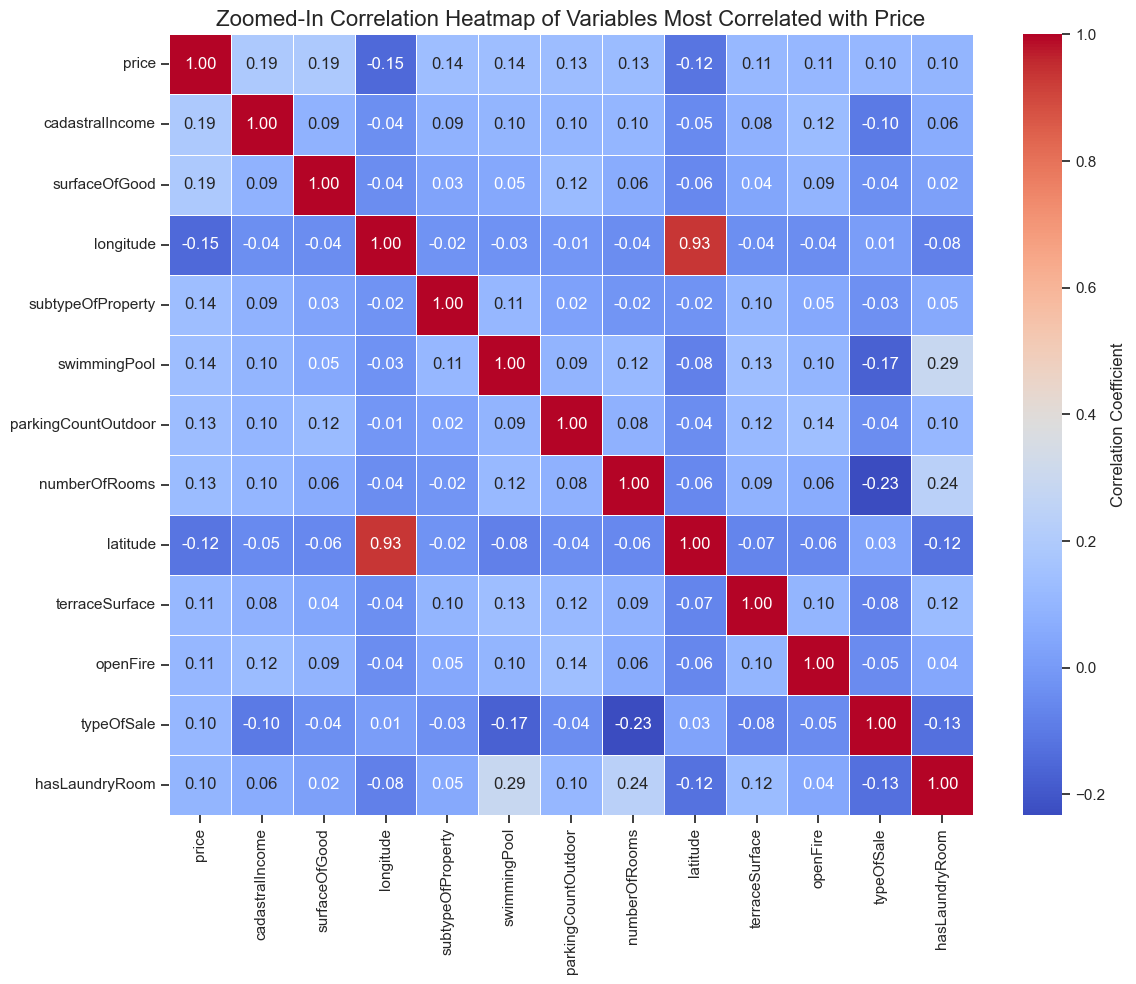

['price',
 'cadastralIncome',
 'surfaceOfGood',
 'longitude',
 'subtypeOfProperty',
 'swimmingPool',
 'parkingCountOutdoor',
 'numberOfRooms',
 'latitude',
 'terraceSurface',
 'openFire',
 'typeOfSale',
 'hasLaundryRoom']

In [37]:
# Select features with strongest correlation to price (absolute value > 0.09)
price_correlations = correlation_matrix['price'].abs().sort_values(ascending=False)
top_correlated = price_correlations[price_correlations > 0.09].index.tolist()

# Always include price in the visualization
if 'price' not in top_correlated:
    top_correlated.append('price')

# Create a smaller correlation matrix with just these features
zoomed_correlation = correlation_matrix.loc[top_correlated, top_correlated]

# Create a figure with appropriate size
plt.figure(figsize=(12, 10))

# Create a heatmap with value labels
heatmap = sns.heatmap(
    zoomed_correlation, 
    annot=True,  # Show values on the heatmap
    cmap='coolwarm',  # Color map
    fmt='.2f',  # Format for the annotations (2 decimal places)
    linewidths=0.5,  # Width of the lines that divide each cell
    cbar_kws={'label': 'Correlation Coefficient'}  # Colorbar label
)

# Set title
plt.title('Zoomed-In Correlation Heatmap of Variables Most Correlated with Price', fontsize=16)

# Adjust layout
plt.tight_layout()

# Display the heatmap
plt.show()
top_correlated

--- 

## Min & Max Price

In [38]:
max = df['price'].max()
min = df['price'].min()

print(f"Max price: {max}")
print(f"Min price: {min}")

Max price: 15000000
Min price: -1


## Price related plots
---
### Price Distribution

<Axes: xlabel='price', ylabel='Count'>

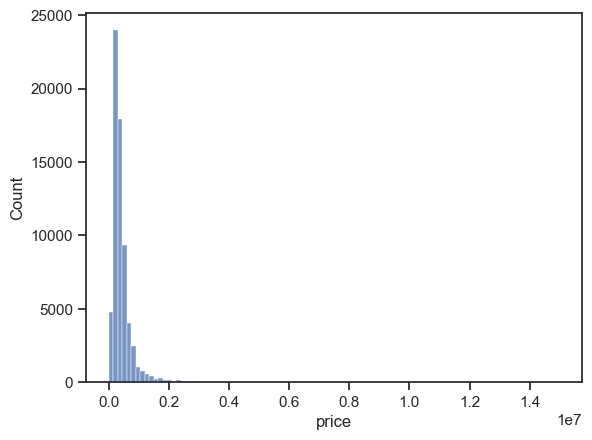

In [39]:
sns.histplot(df['price'], bins=100)

---
### Boxplots: Property Type vs. Price

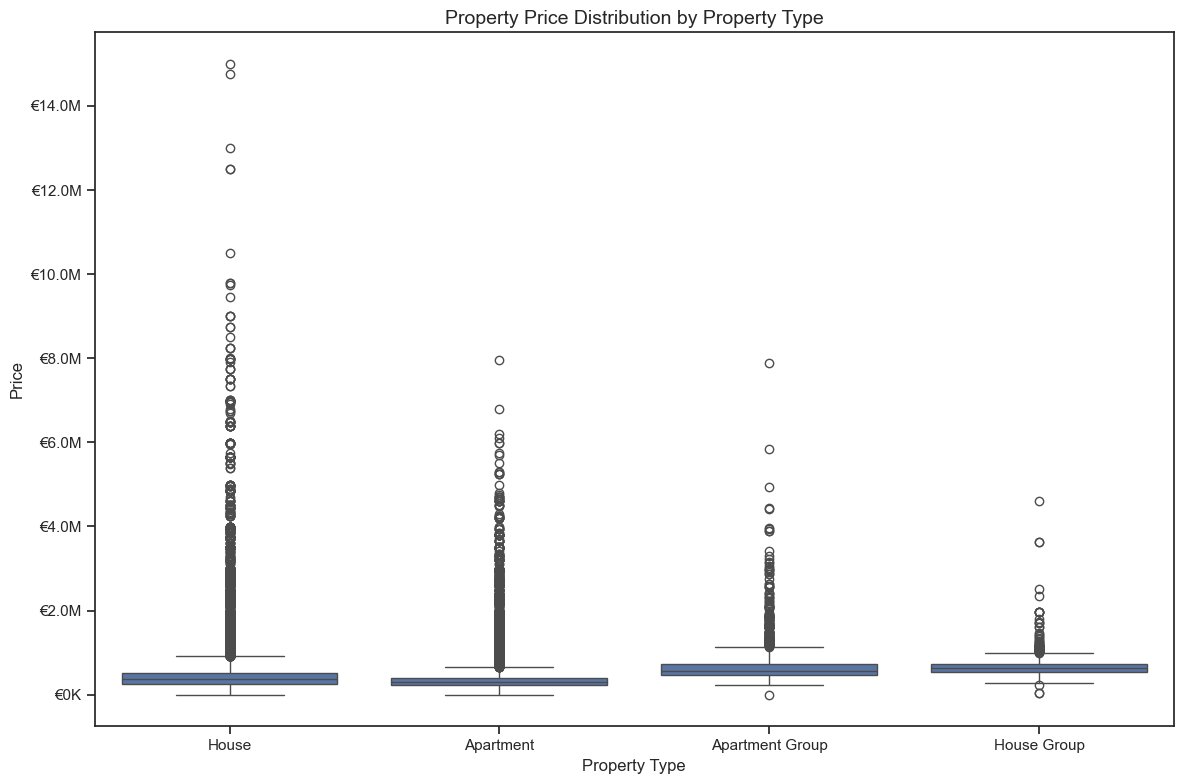

In [40]:
from matplotlib.ticker import FuncFormatter

# Create a mapping for property types
property_types = {0: 'House', 1: 'Apartment', 2: 'House Group', 3: 'Apartment Group'}

# Create a copy with proper labels
df_plot = df.copy()
df_plot['propertyType'] = df_plot['typeOfProperty'].map(property_types)

# Create the figure
plt.figure(figsize=(12, 8))

# Create boxplot with proper labels
sns.boxplot(x='propertyType', y='price', data=df_plot)

# Format the y-axis to show prices in thousands or millions
def price_formatter(x, pos):
    if x >= 1000000:
        return f'€{x/1000000:.1f}M'
    else:
        return f'€{x/1000:.0f}K'

plt.gca().yaxis.set_major_formatter(FuncFormatter(price_formatter))

# Set labels and title
plt.title('Property Price Distribution by Property Type', fontsize=14)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Price', fontsize=12)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

---
### Bar Charts

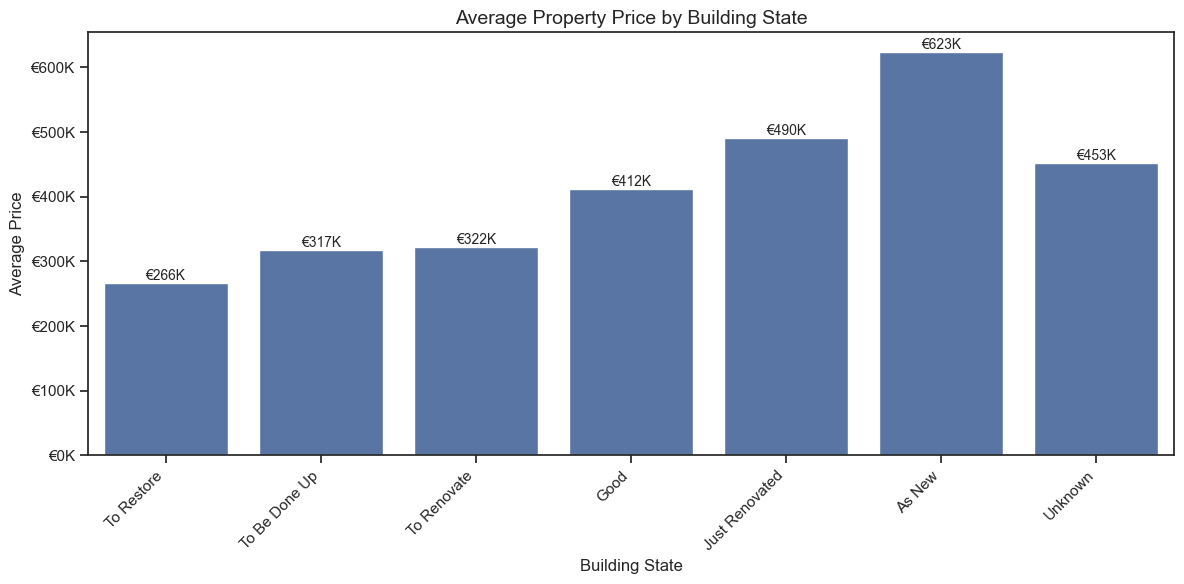

In [41]:
# Create a mapping for building states based on the StateOfBuilding enum
state_mapping = {
    -1: 'Unknown',
    0: 'To Be Done Up',
    1: 'Good',
    2: 'As New',
    3: 'To Renovate',
    4: 'Just Renovated',
    5: 'To Restore'
}

# Calculate mean price for each building state
mean_prices = df.groupby('stateOfBuilding')['price'].mean().reset_index()

# Map the numeric state values to descriptive labels
mean_prices['buildingState'] = mean_prices['stateOfBuilding'].map(state_mapping)

# Define logical order for the building states
order = ['To Restore', 'To Be Done Up', 'To Renovate', 'Good', 'Just Renovated', 'As New', 'Unknown']

# Create the bar chart with better formatting
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='buildingState', y='price', data=mean_prices, order=order)

# Format the y-axis to show prices in thousands, second param is ignored but mandatory for FUncFormatter
def price_formatter(x, pos):
    if x >= 1000000:
        return f'€{x/1000000:.1f}M'
    else:
        return f'€{x/1000:.0f}K'

plt.gca().yaxis.set_major_formatter(FuncFormatter(price_formatter))

# Set labels and title
plt.title('Average Property Price by Building State', fontsize=14)
plt.xlabel('Building State', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{price_formatter(p.get_height(), None)}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom', fontsize=10, rotation=0)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

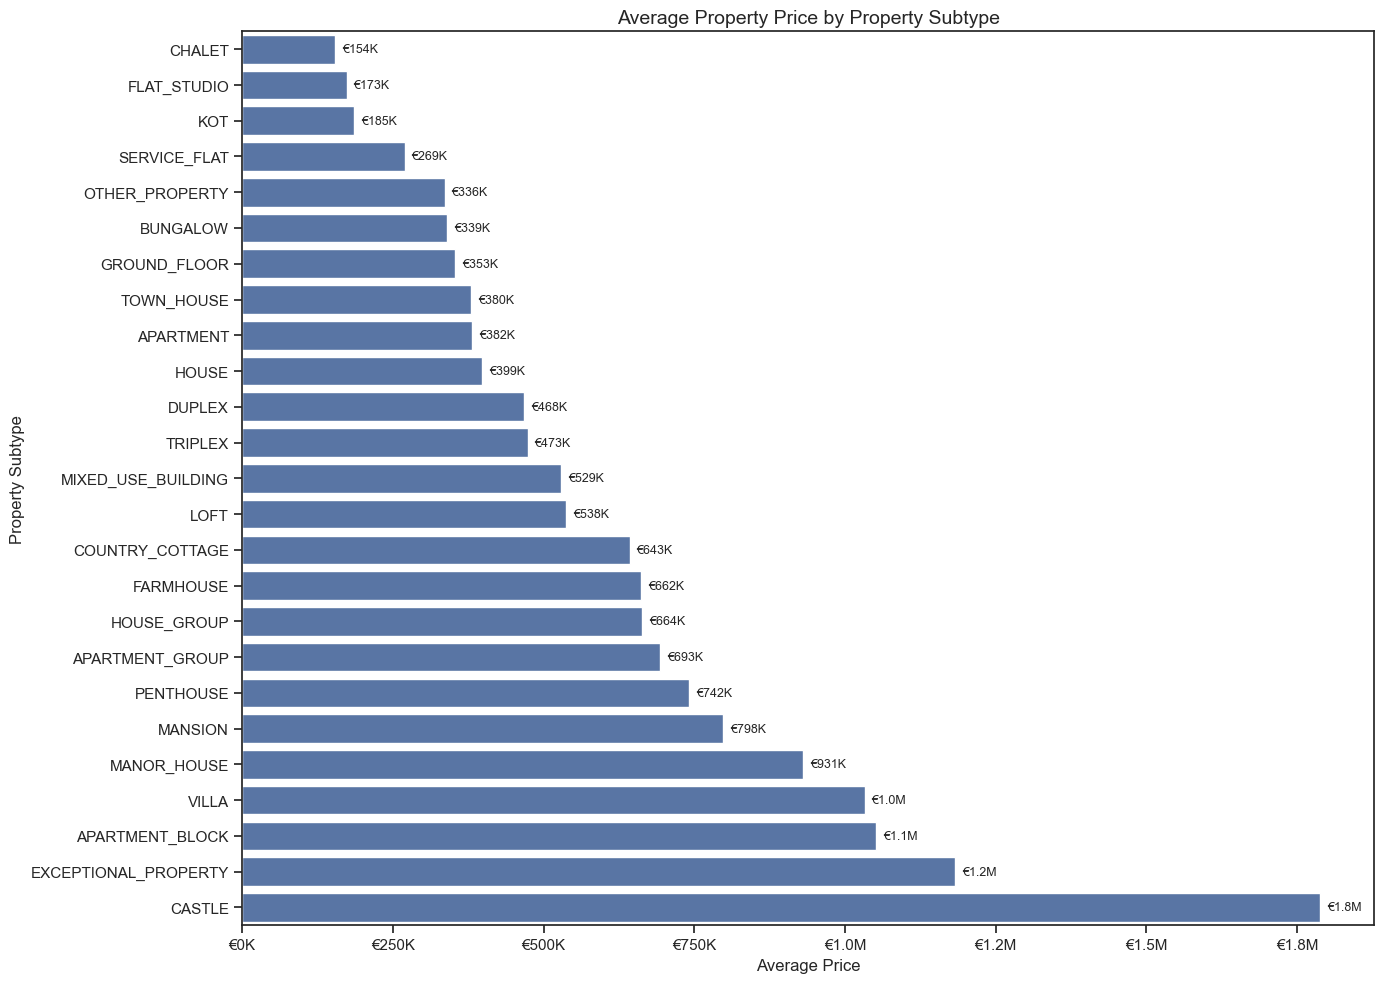

In [42]:
# Create a mapping for subtypes of property
subtype_mapping = {
    0: 'HOUSE',
    1: 'APARTMENT',
    2: 'HOUSE_GROUP',
    3: 'APARTMENT_GROUP',
    4: 'BUNGALOW',
    5: 'CHALET',
    6: 'CASTLE',
    7: 'FARMHOUSE',
    8: 'COUNTRY_COTTAGE',
    9: 'EXCEPTIONAL_PROPERTY',
    10: 'APARTMENT_BLOCK',
    11: 'MIXED_USE_BUILDING',
    12: 'TOWN_HOUSE',
    13: 'MANSION',
    14: 'VILLA',
    15: 'OTHER_PROPERTY',
    16: 'MANOR_HOUSE',
    17: 'PAVILION',
    18: 'GROUND_FLOOR',
    19: 'DUPLEX',
    20: 'TRIPLEX',
    21: 'FLAT_STUDIO',
    22: 'PENTHOUSE',
    23: 'LOFT',
    24: 'KOT',
    25: 'SERVICE_FLAT'
}

# Calculate mean price by subtype of property
subtype_mean_prices = df.groupby('subtypeOfProperty')['price'].mean().reset_index()

# Map the numeric subtype values to descriptive labels
subtype_mean_prices['propertySubtype'] = subtype_mean_prices['subtypeOfProperty'].map(subtype_mapping)

# Sort by average price
subtype_mean_prices = subtype_mean_prices.sort_values('price')

# Create the bar chart with better formatting
plt.figure(figsize=(14, 10))
ax = sns.barplot(x='price', y='propertySubtype', data=subtype_mean_prices)

# Format the x-axis to show prices in thousands or millions
def price_formatter(x, pos):
    if x >= 1000000:
        return f'€{x/1000000:.1f}M'
    else:
        return f'€{x/1000:.0f}K'

plt.gca().xaxis.set_major_formatter(FuncFormatter(price_formatter))

# Set labels and title
plt.title('Average Property Price by Property Subtype', fontsize=14)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Property Subtype', fontsize=12)

# Add data labels on the bars
for p in ax.patches:
    ax.annotate(f'{price_formatter(p.get_width(), None)}', 
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha = 'left', va = 'center', fontsize=9, xytext=(5, 0), 
                textcoords='offset points')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()


C:\Users\ImJus\AppData\Local\Temp\ipykernel_25668\811476212.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='kitchenType', y='price', data=kitchen_prices, palette='viridis')


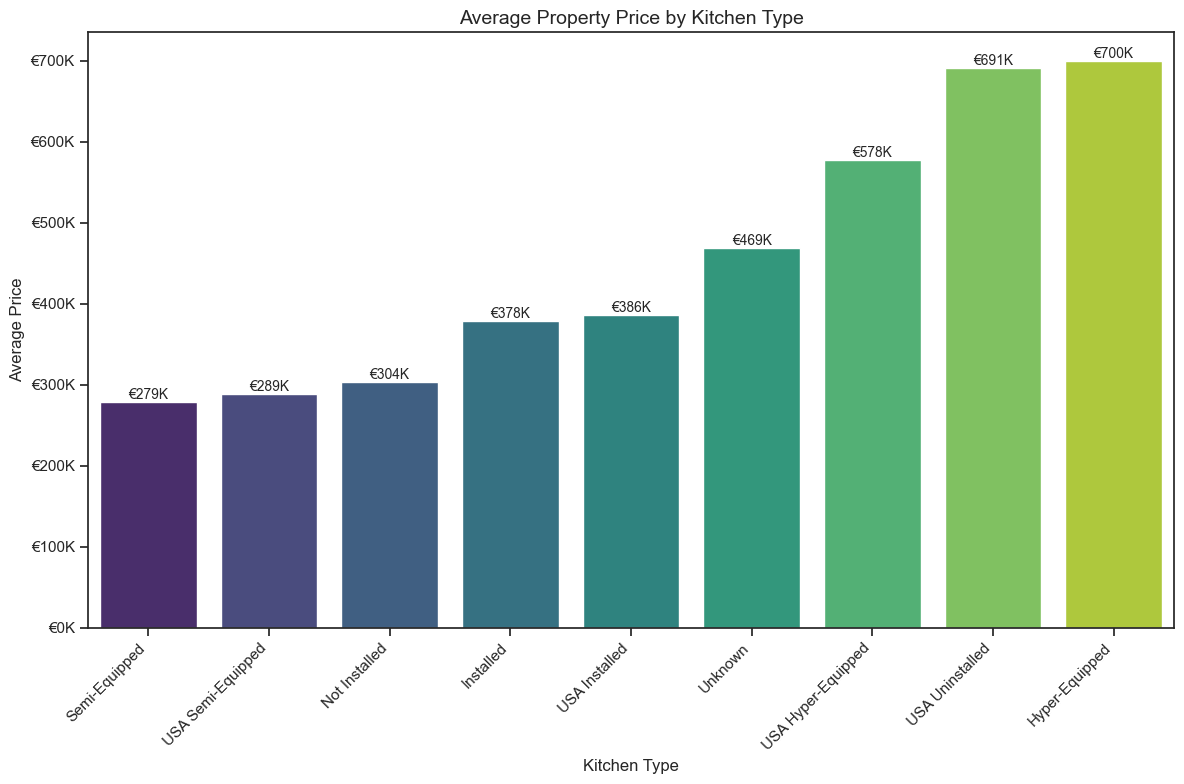

In [43]:
# Create a mapping for equipped kitchen types
kitchen_mapping = {
    -1: 'Unknown',
    0: 'Not Installed',
    1: 'Installed',
    2: 'Semi-Equipped',
    3: 'Hyper-Equipped',
    4: 'USA Uninstalled',
    5: 'USA Installed',
    6: 'USA Semi-Equipped',
    7: 'USA Hyper-Equipped'
}

# Calculate mean price for each kitchen type
kitchen_prices = df.groupby('equippedKitchen')['price'].mean().reset_index()

# Map the numeric kitchen values to descriptive labels
kitchen_prices['kitchenType'] = kitchen_prices['equippedKitchen'].map(kitchen_mapping)

# Sort by average price
kitchen_prices = kitchen_prices.sort_values('price')

# Create the bar chart with better formatting
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='kitchenType', y='price', data=kitchen_prices, palette='viridis')

# Format the y-axis to show prices in thousands or millions
def price_formatter(x, pos):
    if x >= 1000000:
        return f'€{x/1000000:.1f}M'
    else:
        return f'€{x/1000:.0f}K'

plt.gca().yaxis.set_major_formatter(FuncFormatter(price_formatter))

# Set labels and title
plt.title('Average Property Price by Kitchen Type', fontsize=14)
plt.xlabel('Kitchen Type', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{price_formatter(p.get_height(), None)}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom', fontsize=10, rotation=0)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

About 40% of missing values for the heating types so not that respresentative

C:\Users\ImJus\AppData\Local\Temp\ipykernel_25668\1597406386.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y='heatingTypeName', x='price', data=heating_prices, palette='viridis')


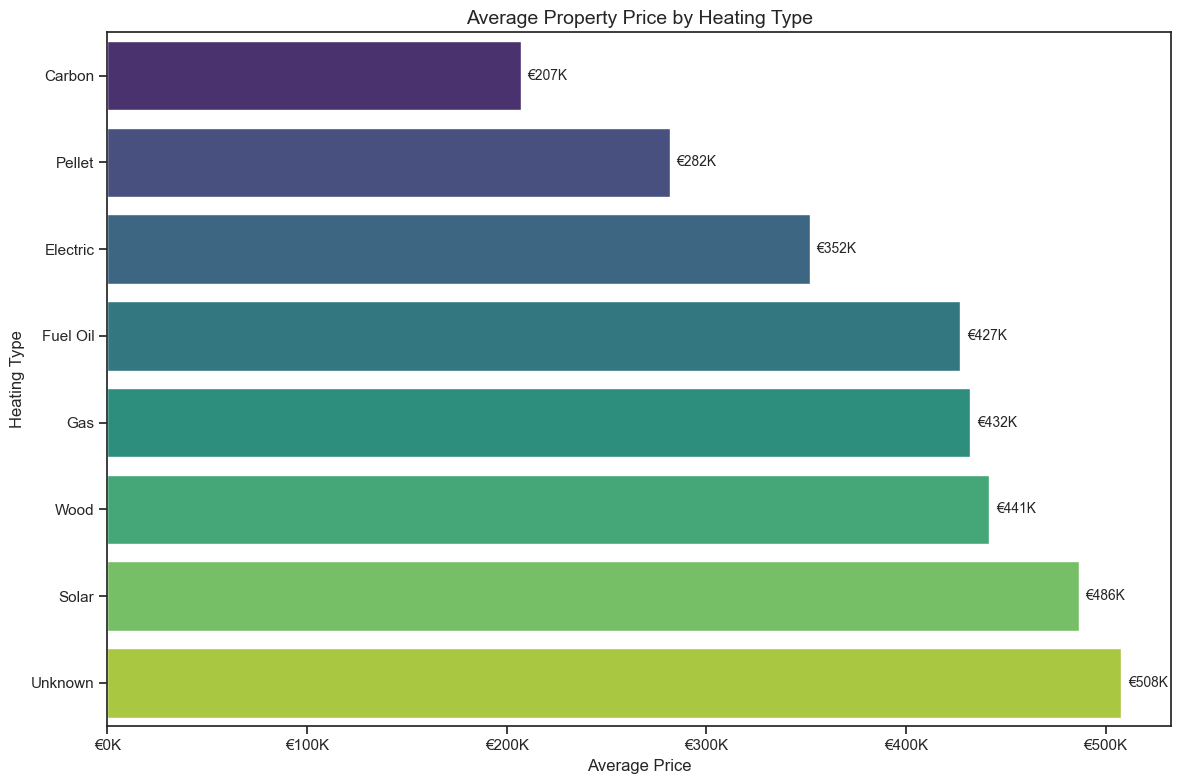

In [44]:
# Create a mapping for heating types
heating_mapping = {
    -1: 'Unknown',
    0: 'Gas',
    1: 'Fuel Oil',
    2: 'Wood',
    3: 'Electric',
    4: 'Pellet',
    5: 'Solar',
    6: 'Carbon'
}

# Calculate mean price for each heating type
heating_prices = df.groupby('heatingType')['price'].mean().reset_index()

# Map the numeric heating values to descriptive labels
heating_prices['heatingTypeName'] = heating_prices['heatingType'].map(heating_mapping)

# Sort by average price
heating_prices = heating_prices.sort_values('price')

# Create the figure
plt.figure(figsize=(12, 8))

# Create horizontal bar chart with better formatting
ax = sns.barplot(y='heatingTypeName', x='price', data=heating_prices, palette='viridis')

# Format the x-axis to show prices in thousands or millions
def price_formatter(x, pos):
    if x >= 1000000:
        return f'€{x/1000000:.1f}M'
    else:
        return f'€{x/1000:.0f}K'

plt.gca().xaxis.set_major_formatter(FuncFormatter(price_formatter))

# Set labels and title
plt.title('Average Property Price by Heating Type', fontsize=14)
plt.xlabel('Average Price', fontsize=12)
plt.ylabel('Heating Type', fontsize=12)

# Add data labels on the bars
for p in ax.patches:
    ax.annotate(f'{price_formatter(p.get_width(), None)}', 
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha = 'left', va = 'center', fontsize=10, xytext=(5, 0), 
                textcoords='offset points')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

C:\Users\ImJus\AppData\Local\Temp\ipykernel_25668\1783550919.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='epcLabel', y='price', data=epc_prices,


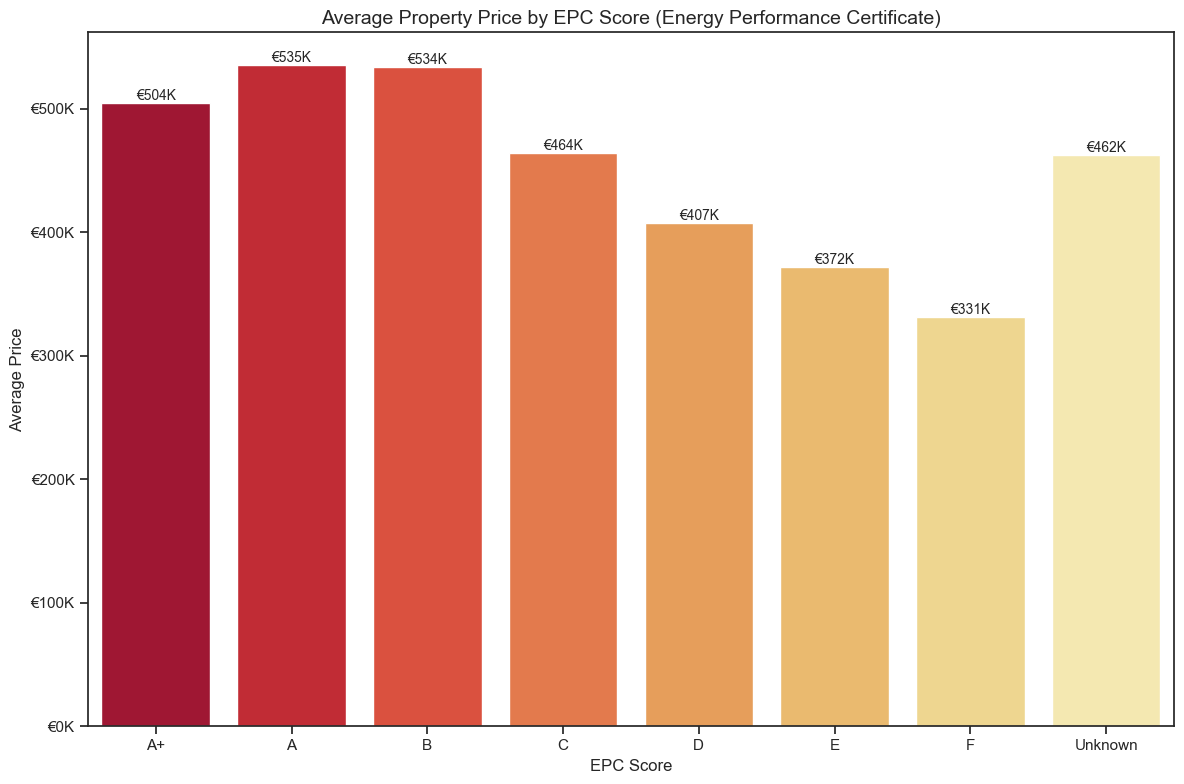

In [45]:
# Create a mapping for EPC scores
epc_mapping = {
    -1: 'Unknown',
    0: 'A+',
    1: 'A',
    2: 'B',
    3: 'C',
    4: 'D',
    5: 'E',
    6: 'F'
}

# Calculate mean price for each EPC score
epc_prices = df.groupby('epcScore')['price'].mean().reset_index()

# Map the numeric EPC values to descriptive labels
epc_prices['epcLabel'] = epc_prices['epcScore'].map(epc_mapping)

# Define logical order for the EPC scores (best to worst, with Unknown at the end)
epc_order = ['A+', 'A', 'B', 'C', 'D', 'E', 'F', 'Unknown']

# Create the figure
plt.figure(figsize=(12, 8))

# Create bar chart with better formatting
ax = sns.barplot(x='epcLabel', y='price', data=epc_prices, 
                order=[label for label in epc_order if label in epc_prices['epcLabel'].values], 
                palette='YlOrRd_r')

# Format the y-axis to show prices in thousands or millions
def price_formatter(x, pos):
    if x >= 1000000:
        return f'€{x/1000000:.1f}M'
    else:
        return f'€{x/1000:.0f}K'

plt.gca().yaxis.set_major_formatter(FuncFormatter(price_formatter))

# Set labels and title
plt.title('Average Property Price by EPC Score (Energy Performance Certificate)', fontsize=14)
plt.xlabel('EPC Score', fontsize=12)
plt.ylabel('Average Price', fontsize=12)

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{price_formatter(p.get_height(), None)}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'bottom', fontsize=10, rotation=0)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

---

## Scatter Plots

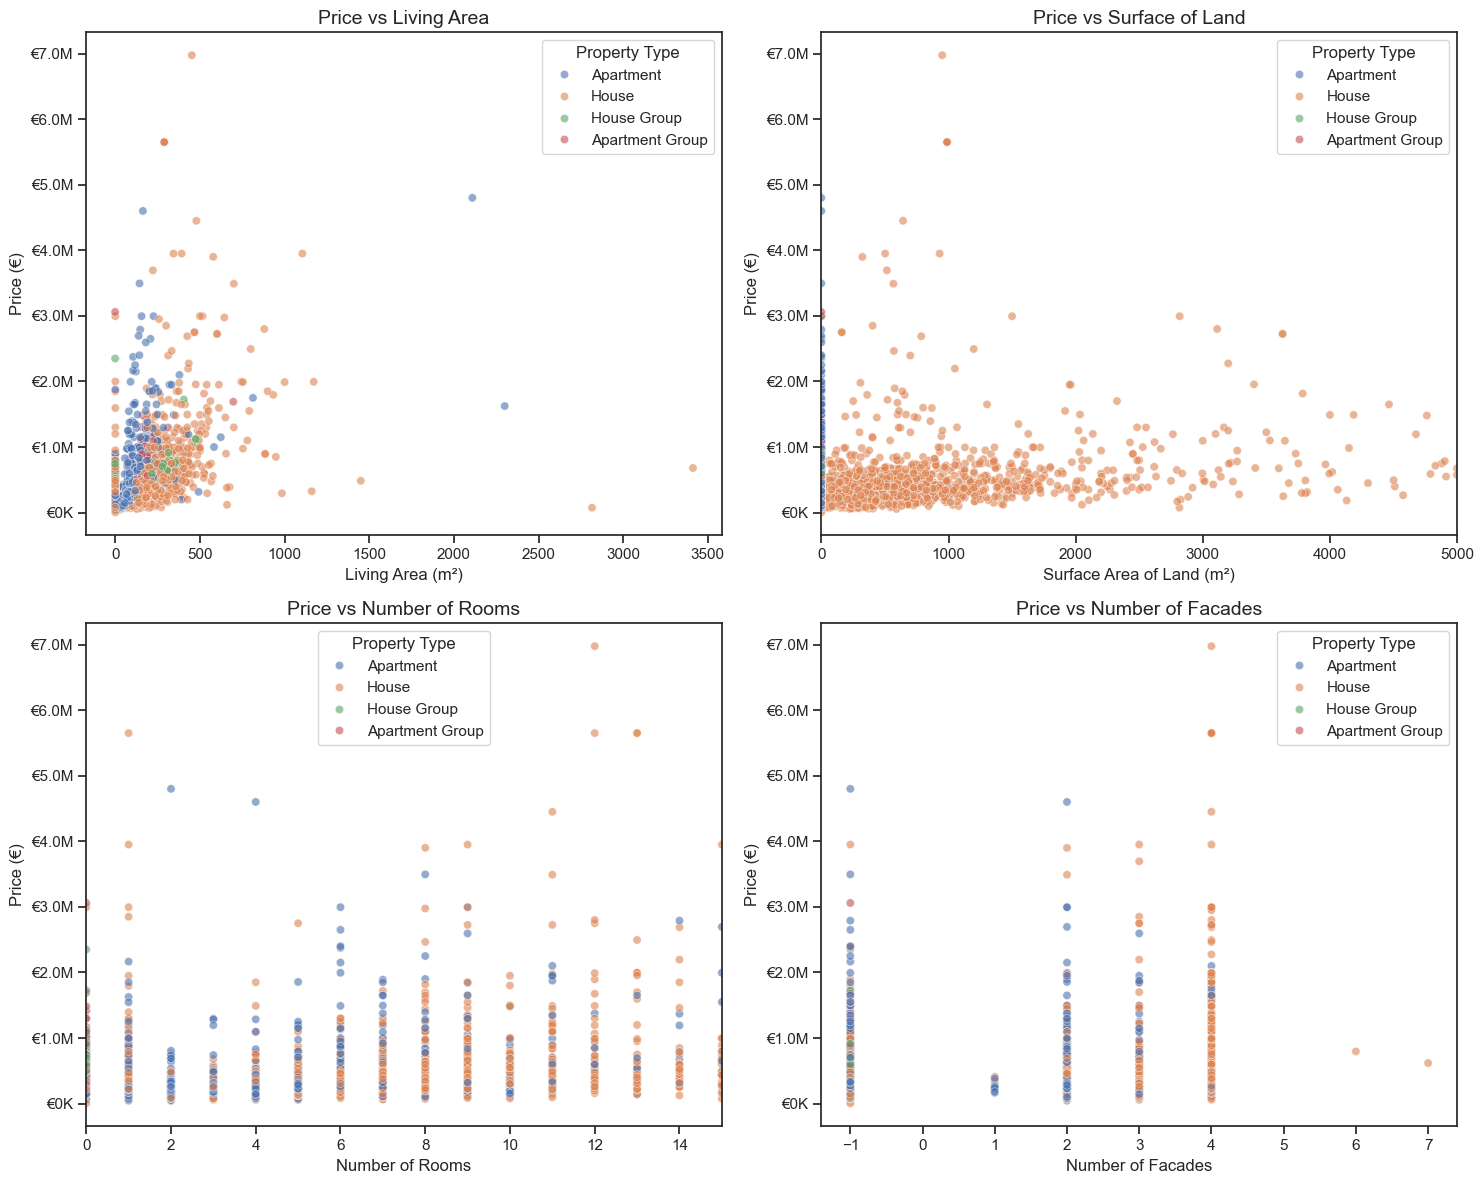

C:\Users\ImJus\AppData\Local\Temp\ipykernel_25668\1100405486.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


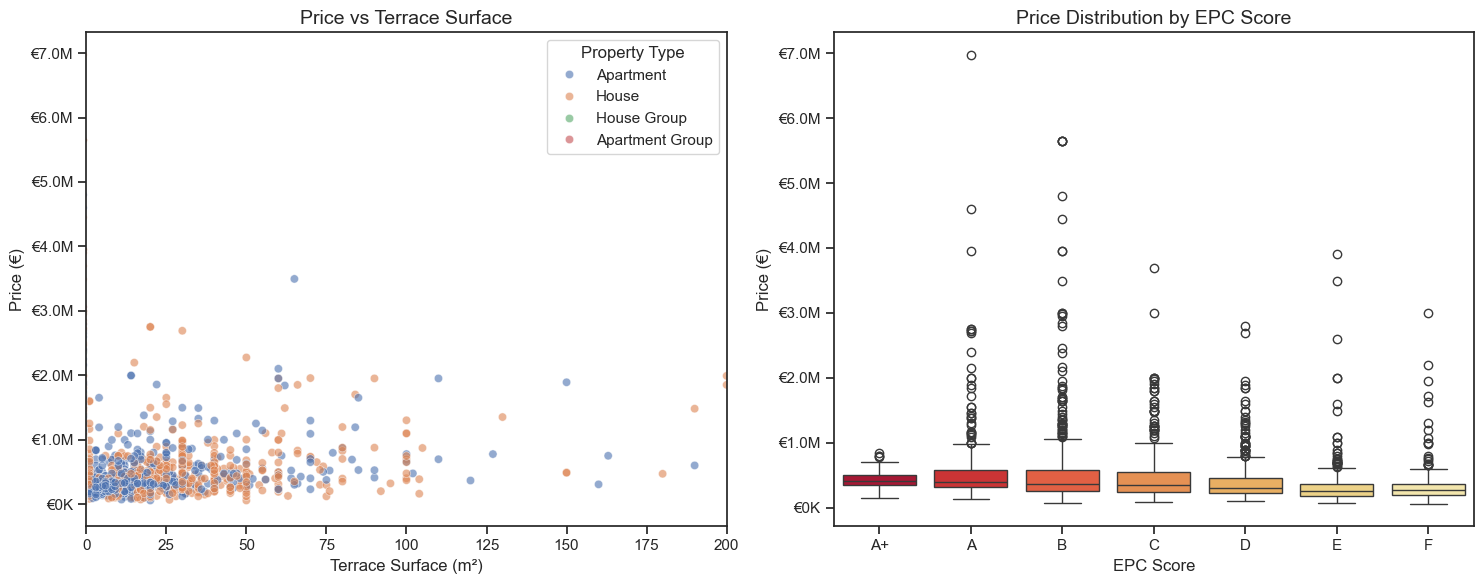

In [46]:
# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Sample data for faster plotting (5% of the original dataset)
sample_size = int(len(df) * 0.05)
df_sample = df.sample(n=sample_size, random_state=42)

# 1. Price vs Living Area scatter plot
sns.scatterplot(
    x='livingArea', 
    y='price', 
    hue='propertyType',
    data=df_plot.sample(n=sample_size, random_state=42),
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Price vs Living Area', fontsize=14)
axes[0].set_xlabel('Living Area (m²)', fontsize=12)
axes[0].set_ylabel('Price (€)', fontsize=12)
axes[0].yaxis.set_major_formatter(FuncFormatter(price_formatter))
axes[0].legend(title='Property Type')

# 2. Price vs Surface of Land/Good
sns.scatterplot(
    x='surfaceOfGood', 
    y='price', 
    hue='propertyType',
    data=df_plot.sample(n=sample_size, random_state=42),
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title('Price vs Surface of Land', fontsize=14)
axes[1].set_xlabel('Surface Area of Land (m²)', fontsize=12)
axes[1].set_ylabel('Price (€)', fontsize=12)
axes[1].yaxis.set_major_formatter(FuncFormatter(price_formatter))
# Set a reasonable limit for x-axis to avoid extreme outliers
axes[1].set_xlim(0, 5000)
axes[1].legend(title='Property Type')

# 3. Price vs Number of Rooms
sns.scatterplot(
    x='numberOfRooms', 
    y='price', 
    hue='propertyType',
    data=df_plot.sample(n=sample_size, random_state=42),
    alpha=0.6,
    ax=axes[2]
)
axes[2].set_title('Price vs Number of Rooms', fontsize=14)
axes[2].set_xlabel('Number of Rooms', fontsize=12)
axes[2].set_ylabel('Price (€)', fontsize=12)
axes[2].yaxis.set_major_formatter(FuncFormatter(price_formatter))
# Limit x-axis to show meaningful range
axes[2].set_xlim(0, 15)
axes[2].legend(title='Property Type')

# 4. Price vs Number of Facades
sns.scatterplot(
    x='numberOfFacades', 
    y='price', 
    hue='propertyType',
    data=df_plot.sample(n=sample_size, random_state=42),
    alpha=0.6,
    ax=axes[3]
)
axes[3].set_title('Price vs Number of Facades', fontsize=14)
axes[3].set_xlabel('Number of Facades', fontsize=12)
axes[3].set_ylabel('Price (€)', fontsize=12)
axes[3].yaxis.set_major_formatter(FuncFormatter(price_formatter))
axes[3].legend(title='Property Type')

plt.tight_layout()
plt.show()

# Create additional scatter plots for other relationships
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Price vs Terrace Surface
sns.scatterplot(
    x='terraceSurface', 
    y='price', 
    hue='propertyType',
    data=df_plot.sample(n=sample_size, random_state=42),
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Price vs Terrace Surface', fontsize=14)
axes[0].set_xlabel('Terrace Surface (m²)', fontsize=12)
axes[0].set_ylabel('Price (€)', fontsize=12)
axes[0].yaxis.set_major_formatter(FuncFormatter(price_formatter))
# Limit to meaningful range to avoid outliers
axes[0].set_xlim(0, 200)
axes[0].legend(title='Property Type')

# 2. Price vs EPC Score - Use the mapping to show categorical scores
# Create a copy with proper labels
plot_data = df_plot.sample(n=sample_size, random_state=42).copy()
plot_data['epcLabel'] = plot_data['epcScore'].map(epc_mapping)

# Filter out missing values
valid_data = plot_data[plot_data['epcScore'] >= 0]

# Use the custom order from epc_order
order = [label for label in epc_order if label != 'Unknown']

# Create violinplot instead of scatter for categorical data
sns.boxplot(
    x='epcLabel', 
    y='price', 
    data=valid_data,
    order=order,
    palette='YlOrRd_r',
    ax=axes[1]
)
axes[1].set_title('Price Distribution by EPC Score', fontsize=14)
axes[1].set_xlabel('EPC Score', fontsize=12)
axes[1].set_ylabel('Price (€)', fontsize=12)
axes[1].yaxis.set_major_formatter(FuncFormatter(price_formatter))

plt.tight_layout()
plt.show()

---

## Pair Plots

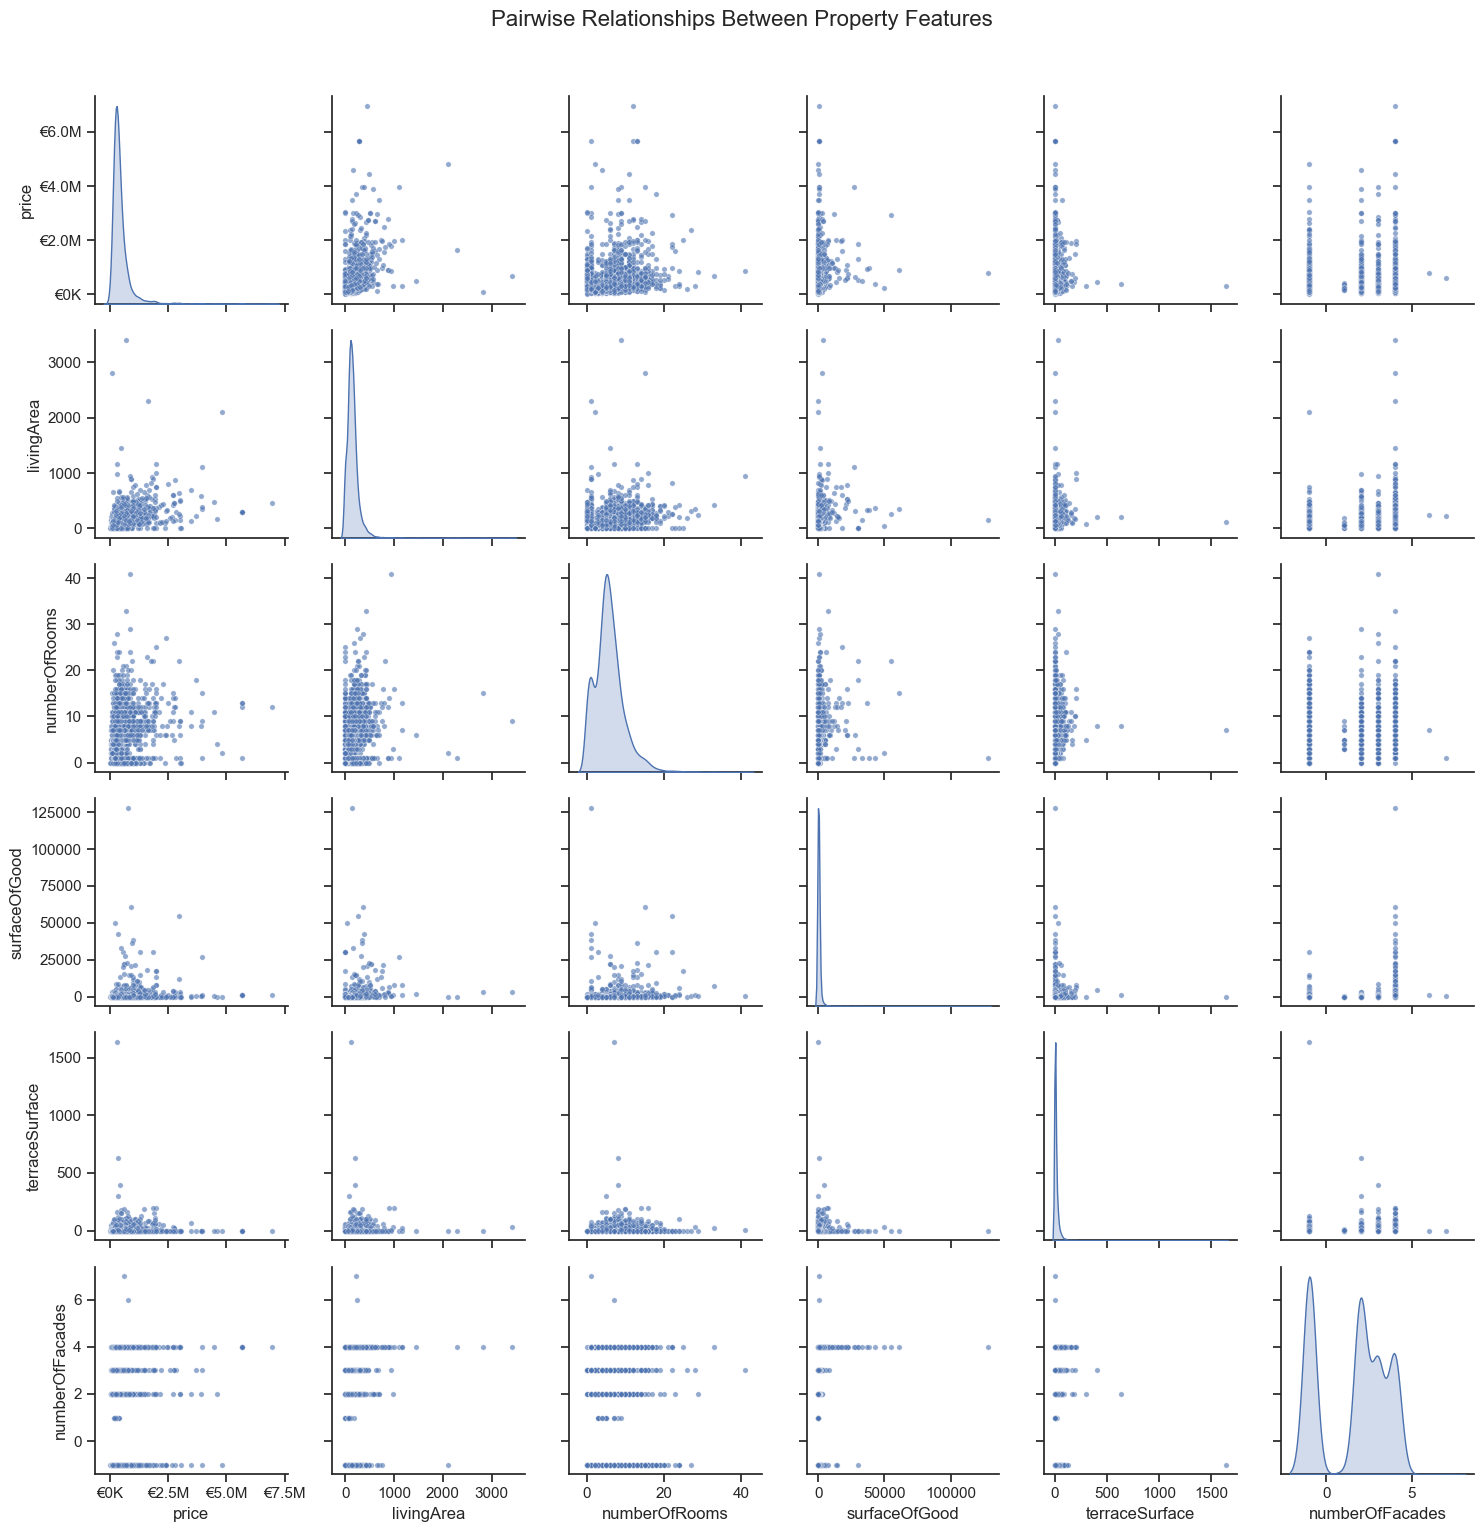

In [47]:
# Select the most relevant features for the pairplot
features_for_pairplot = [
    'price', 
    'livingArea', 
    'numberOfRooms', 
    'surfaceOfGood', 
    'terraceSurface', 
    'numberOfFacades'
]

# Create a sample of the data (pairplots can be computationally intensive)
# Taking a 5% sample to make visualization faster but still representative
sample_size = int(len(df) * 0.05)  # 5% of the data
df_sample = df.sample(n=sample_size, random_state=42)

# Create the pairplot with price colored by property type
sns.set(style="ticks")
g = sns.pairplot(
    df_sample[features_for_pairplot], 
    diag_kind="kde",  # Kernel density estimation for the diagonal
    plot_kws={'alpha': 0.6, 's': 15},  # Make points semi-transparent
    height=2.5  # Adjust size of each subplot
)

# Format the axis labels to be more readable for price values
def format_price_ticks(ax, x=True, y=True):
    if x:
        ticker = ax.xaxis
        if ticker.label.get_text() == 'price':
            ticker.set_major_formatter(FuncFormatter(price_formatter))
    if y: 
        ticker = ax.yaxis
        if ticker.label.get_text() == 'price':
            ticker.set_major_formatter(FuncFormatter(price_formatter))

# Apply formatting to all subplots
for i in range(len(features_for_pairplot)):
    for j in range(len(features_for_pairplot)):
        ax = g.axes[i, j]
        format_price_ticks(ax)

# Set title for the entire figure
plt.suptitle('Pairwise Relationships Between Property Features', 
             fontsize=16, 
             y=1.02)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()